# Chest X-Ray Pneumonia Classifier
## Stage 1 Project — Medical Image Computer Vision

In this notebook you will:

Install required libraries
Download and explore the dataset
Preprocess and load the images
Build a classifier using pretrained ResNet18
Train and evaluate the model
Make predictions on new images
Dataset: Kaggle Chest X-Ray Dataset
Classes: NORMAL vs PNEUMONIA
Tip: Run on Google Colab with GPU for faster training (Runtime → Change runtime type → GPU)

# 📦 Cell 1 — Install Libraries

In [ ]:
# Install required libraries
!pip install torch torchvision matplotlib pillow tqdm scikit-learn seaborn --quiet
print("✅ Libraries installed!")

📥 Cell 2 — Download Dataset¶
Option A — Google Colab (recommended):

In [1]:
# Upload your kaggle.json API key first, then run:
!pip install kaggle --quiet
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip

cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:11<00:00, 221MB/s]



In [5]:
# ---- Run this if using Google Colab with Kaggle API ----
# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
# !unzip -q chest-xray-pneumonia.zip

import os

DATA_DIR = "\:kaggle"

if os.path.exists(DATA_DIR):
    print("✅ Dataset found!")
    for split in ['train', 'val', 'test']:
        for cls in ['NORMAL', 'PNEUMONIA']:
            path = os.path.join(DATA_DIR, split, cls)
            count = len(os.listdir(path)) if os.path.exists(path) else 0
            print(f"  {split}/{cls}: {count} images")
else:
    print("❌ Dataset not found. Please download it first (see instructions above).")

❌ Dataset not found. Please download it first (see instructions above).


<>:10: SyntaxWarning: invalid escape sequence '\:'
<>:10: SyntaxWarning: invalid escape sequence '\:'
/tmp/ipykernel_3843/2223497543.py:10: SyntaxWarning: invalid escape sequence '\:'
  DATA_DIR = "\:kaggle"


In [6]:
import os

DATA_DIR = "/content/chest_xray"

if os.path.exists(DATA_DIR):
    print("✅ Dataset found!")
    for split in ['train', 'val', 'test']:
        for cls in ['NORMAL', 'PNEUMONIA']:
            path = os.path.join(DATA_DIR, split, cls)
            count = len(os.listdir(path)) if os.path.exists(path) else 0
            print(f"  {split}/{cls}: {count} images")
else:
    print("❌ Dataset not found. Please download it first (see instructions above).")

✅ Dataset found!
  train/NORMAL: 1341 images
  train/PNEUMONIA: 3875 images
  val/NORMAL: 8 images
  val/PNEUMONIA: 8 images
  test/NORMAL: 234 images
  test/PNEUMONIA: 390 images


# 🔍 Cell 3 — Explore & Visualize Sample Images

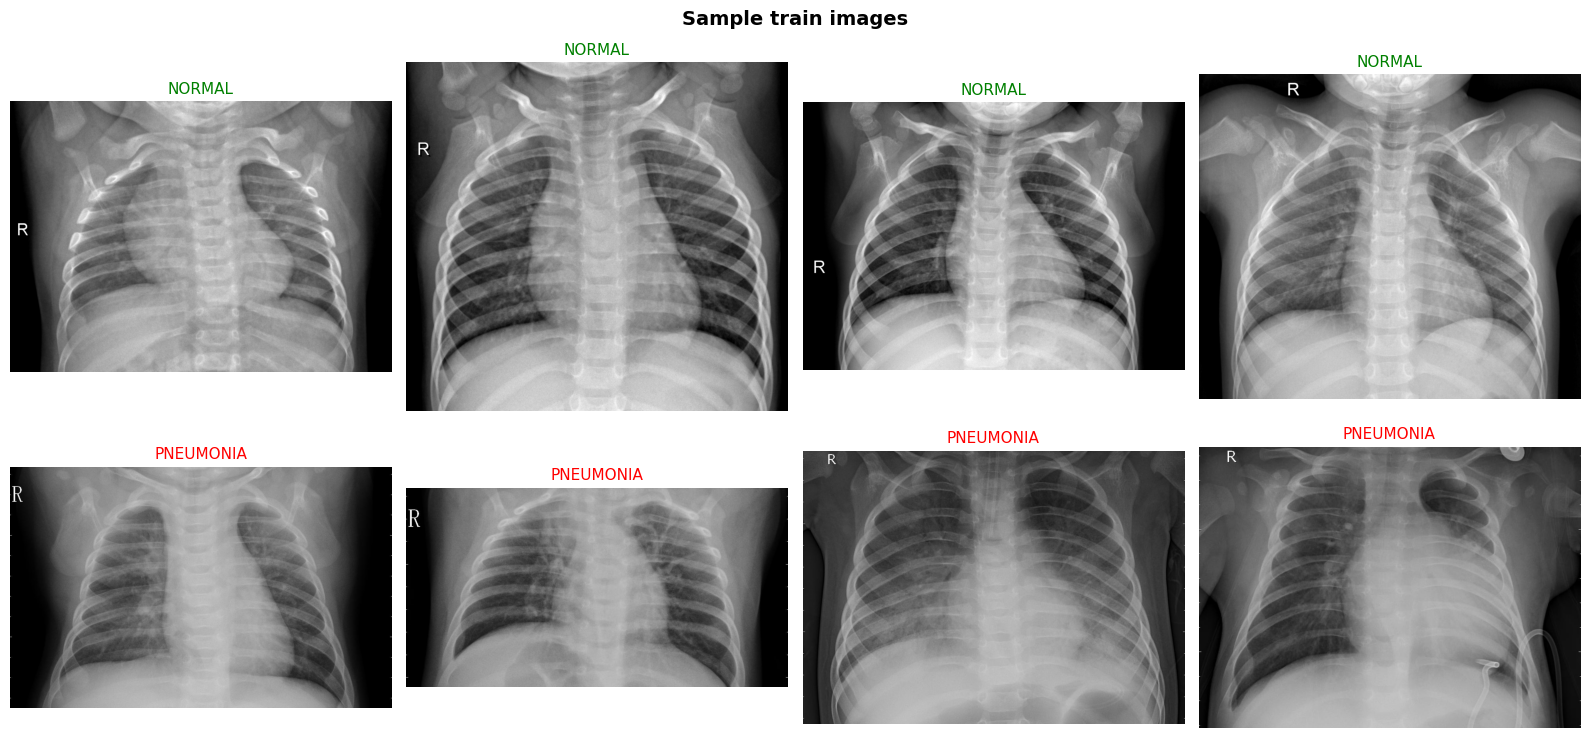

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_sample_images(data_dir, split='train', n=4):
    fig, axes = plt.subplots(2, n, figsize=(16, 8))
    fig.suptitle(f'Sample {split} images', fontsize=14, fontweight='bold')

    for col, cls in enumerate(['NORMAL', 'PNEUMONIA']):
        folder = os.path.join(data_dir, split, cls)
        files = random.sample(os.listdir(folder), n)
        for i, fname in enumerate(files):
            img = Image.open(os.path.join(folder, fname)).convert('RGB')
            axes[col][i].imshow(img, cmap='gray')
            axes[col][i].set_title(cls, fontsize=11,
                                   color='green' if cls == 'NORMAL' else 'red')
            axes[col][i].axis('off')

    plt.tight_layout()
    plt.show()

show_sample_images(DATA_DIR, split='train', n=4)

# Cell 4 — Preprocess & Load Data

In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Image transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),       # augmentation: random flip
    transforms.RandomRotation(10),           # augmentation: slight rotation
    transforms.ColorJitter(brightness=0.2),  # augmentation: brightness
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],          # ImageNet mean
        std=[0.229, 0.224, 0.225]            # ImageNet std
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load datasets
train_dataset = datasets.ImageFolder(DATA_DIR + "/train", transform=train_transforms)
val_dataset   = datasets.ImageFolder(DATA_DIR + "/val",   transform=val_transforms)
test_dataset  = datasets.ImageFolder(DATA_DIR + "/test",  transform=val_transforms)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

CLASS_NAMES = train_dataset.classes
print(f"Classes: {CLASS_NAMES}")
print(f"Train : {len(train_dataset):,} images")
print(f"Val   : {len(val_dataset):,} images")
print(f"Test  : {len(test_dataset):,} images")

Classes: ['NORMAL', 'PNEUMONIA']
Train : 5,216 images
Val   : 16 images
Test  : 624 images


# Cell 5 — Build Model (Pretrained ResNet18)

In [9]:
import torch.nn as nn
from torchvision import models

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer for 2 classes
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(512, 2)
)

model = model.to(device)

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,}")
print(f"Total params     : {total:,}")
print(f"Frozen params    : {total - trainable:,}")

Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Trainable params : 1,026
Total params     : 11,177,538
Frozen params    : 11,176,512


 Cell 6 — Set Up Loss & Optimizer

In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

# Only optimize the final layer parameters
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Learning rate scheduler — reduce LR if val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

print("✅ Loss, optimizer, and scheduler ready.")

✅ Loss, optimizer, and scheduler ready.


Cell 7 — Train the Model

In [11]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in tqdm(loader, desc="  Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# Training loop
EPOCHS = 5
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_acc = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2%}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_xray_model.pth")
        print(f"  ✅ Best model saved! (val_acc: {best_val_acc:.2%})")

print("\n🎉 Training complete!")


Epoch 1/5


  Train Loss: 0.3302 | Train Acc: 85.05%
  Val   Loss: 0.3316 | Val   Acc: 81.25%
  ✅ Best model saved! (val_acc: 81.25%)

Epoch 2/5


  Train Loss: 0.2352 | Train Acc: 90.26%
  Val   Loss: 0.2656 | Val   Acc: 81.25%

Epoch 3/5


  Train Loss: 0.2070 | Train Acc: 91.81%
  Val   Loss: 0.3114 | Val   Acc: 81.25%

Epoch 4/5


  Train Loss: 0.1931 | Train Acc: 92.06%
  Val   Loss: 0.2386 | Val   Acc: 87.50%
  ✅ Best model saved! (val_acc: 87.50%)

Epoch 5/5


  Train Loss: 0.1880 | Train Acc: 92.33%
  Val   Loss: 0.2327 | Val   Acc: 87.50%

🎉 Training complete!


 Cell 8 — Plot Training Curves

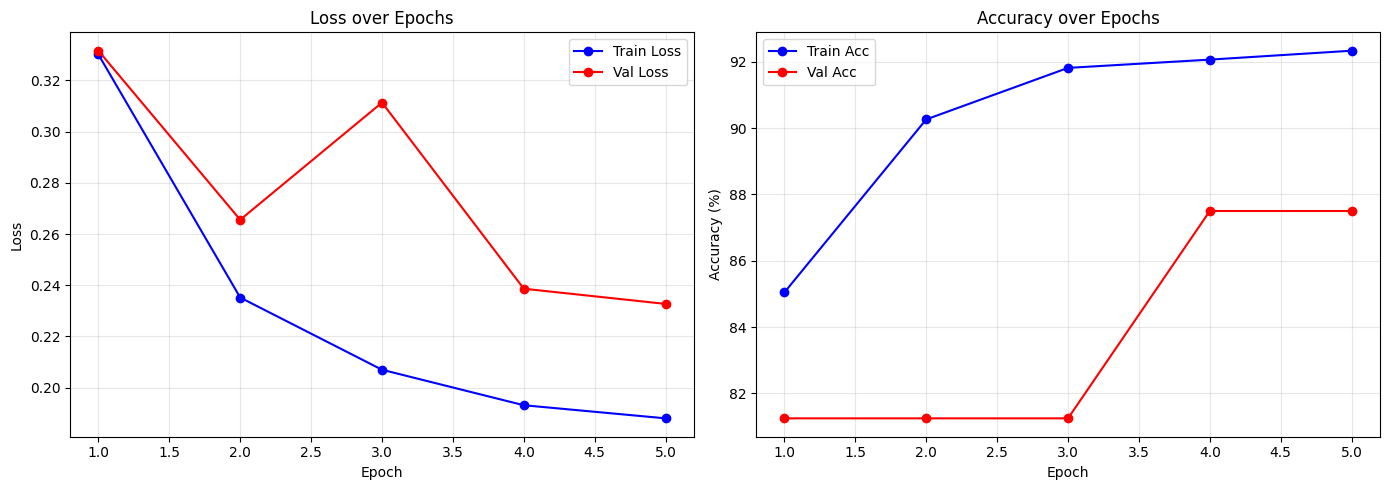

📈 Training curves saved as training_curves.png


In [12]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("📈 Training curves saved as training_curves.png")

# Evaluate on Test Set + Confusion Matrix

Testing: 100%|██████████| 20/20 [00:45<00:00,  2.28s/it]



📋 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.93      0.80      0.86       234
   PNEUMONIA       0.89      0.96      0.92       390

    accuracy                           0.90       624
   macro avg       0.91      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624



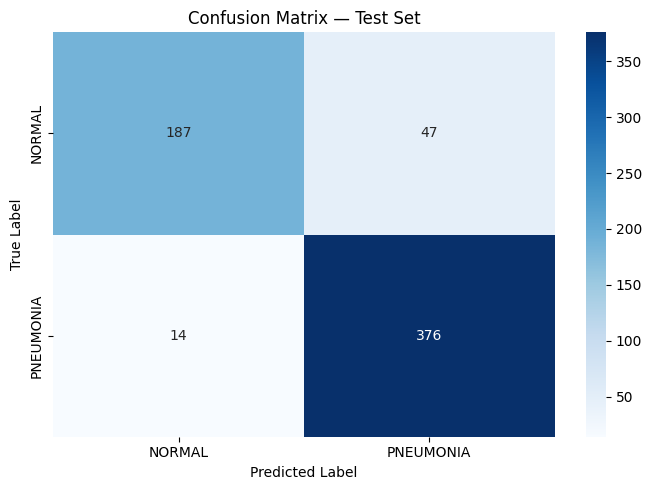

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Load best model
model.load_state_dict(torch.load("best_xray_model.pth", map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Classification report
print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

# Cell 10 — Predict on a Single Image

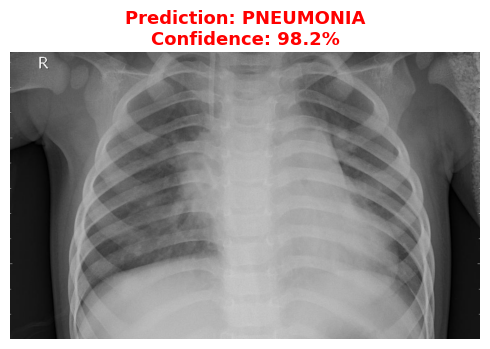

Result     : PNEUMONIA
Confidence : 98.2%
  NORMAL: 1.8%
  PNEUMONIA: 98.2%


In [14]:
import torch.nn.functional as F

def predict_image(image_path, model, transform, class_names, device):
    """Predict the class of a single X-ray image."""
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)  # add batch dim

    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs  = F.softmax(output, dim=1)[0]

    pred_idx   = probs.argmax().item()
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx].item()

    # Display result
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(img, cmap='gray')
    color = 'green' if pred_class == 'NORMAL' else 'red'
    ax.set_title(f"Prediction: {pred_class}\nConfidence: {confidence:.1%}",
                 fontsize=13, color=color, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Result     : {pred_class}")
    print(f"Confidence : {confidence:.1%}")
    for i, cls in enumerate(class_names):
        print(f"  {cls}: {probs[i].item():.1%}")

# --- Try it on a test image ---
# Change this path to any X-ray image you want to test
TEST_IMAGE = DATA_DIR + "/test/PNEUMONIA/" + os.listdir(DATA_DIR + "/test/PNEUMONIA/")[0]

predict_image(TEST_IMAGE, model, val_transforms, CLASS_NAMES, device)